# Recall

<ipython-input-4-983f56b984bc>:93: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(
<ipython-input-4-983f56b984bc>:93: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(
<ipython-input-4-983f56b984bc>:114: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-4-983f56b984bc>:114: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-4-983f56b984bc>:114: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-4-983f56b984bc>:114: FutureWarning

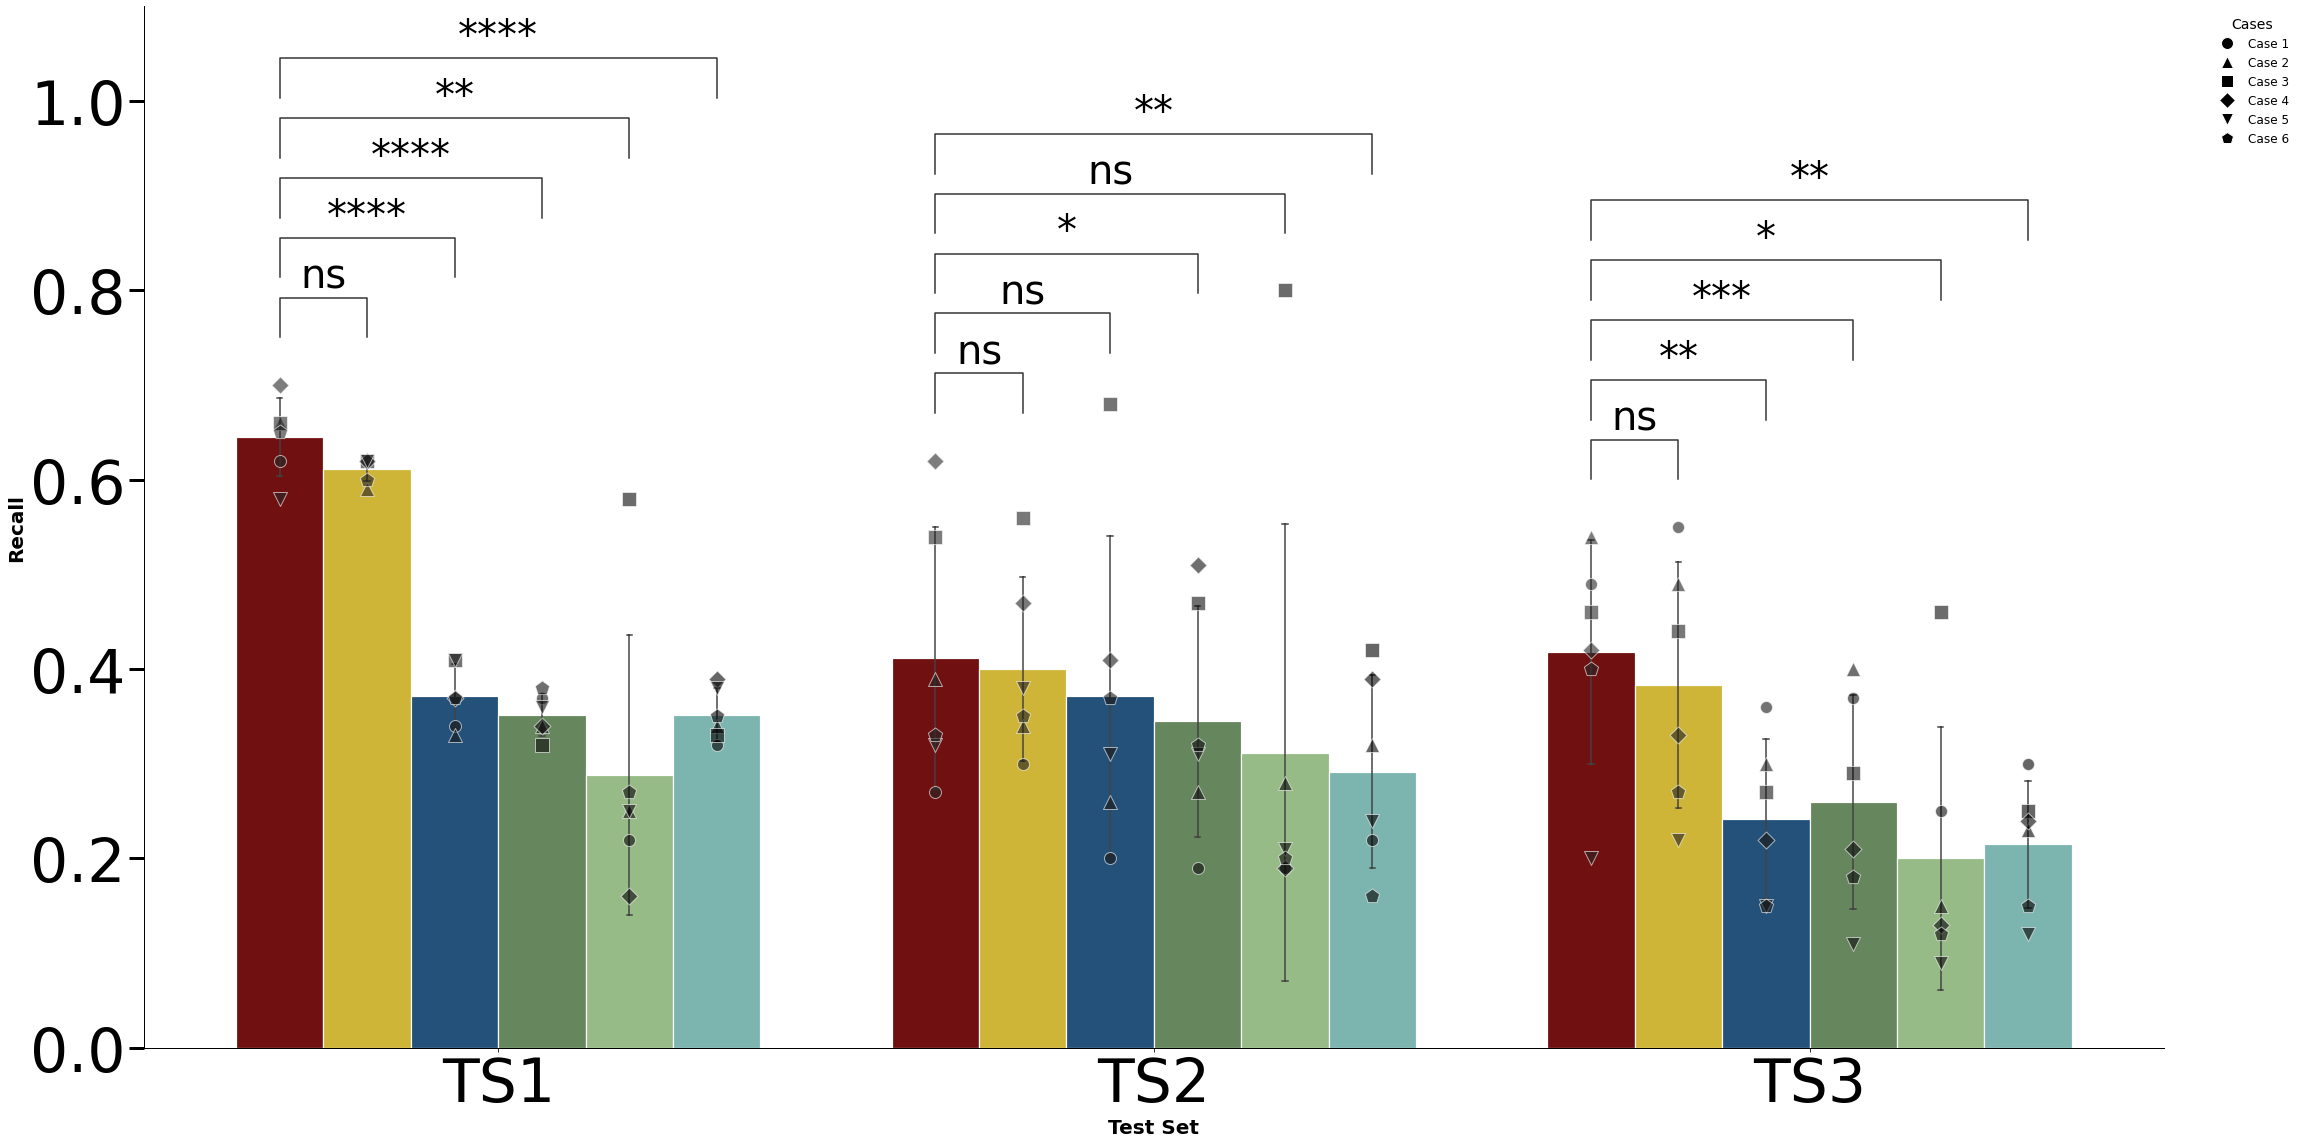

<Figure size 432x288 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import seaborn as sns
import numpy as np
from itertools import combinations

# ==========================================
# 1. SETUP DATA
# ==========================================

raw_data = {
    'TS1': {
        'base_model': [0.62, 0.66, 0.66, 0.7, 0.58, 0.65],
        'random_walk_with_topology': [0.62, 0.59, 0.62, 0.62, 0.62, 0.6],
        'random_edges': [0.34, 0.33, 0.41, 0.37, 0.41, 0.37],
        'random_pdb_edges': [0.37, 0.34, 0.32, 0.34, 0.36, 0.38],
        'random_walk_with_random_edges': [0.22, 0.25, 0.58, 0.16, 0.25, 0.27],
        'random_walk_with_topology_v2': [0.32, 0.34, 0.33, 0.39, 0.38, 0.35],
    },
    'TS2': {
        'base_model': [0.27, 0.39, 0.54, 0.62, 0.32, 0.33],
        'random_walk_with_topology': [0.3, 0.34, 0.56, 0.47, 0.38, 0.35],
        'random_edges': [0.2, 0.26, 0.68, 0.41, 0.31, 0.37],
        'random_pdb_edges': [0.19, 0.27, 0.47, 0.51, 0.31, 0.32],
        'random_walk_with_random_edges': [0.19, 0.28, 0.8, 0.19, 0.21, 0.2],
        'random_walk_with_topology_v2': [0.22, 0.32, 0.42, 0.39, 0.24, 0.16],
    },
    'TS3': {
        'base_model': [0.49, 0.54, 0.46, 0.42, 0.2, 0.4],
        'random_walk_with_topology': [0.55, 0.49, 0.44, 0.33, 0.22, 0.27],
        'random_edges': [0.36, 0.3, 0.27, 0.22, 0.15, 0.15],
        'random_pdb_edges': [0.37, 0.4, 0.29, 0.21, 0.11, 0.18],
        'random_walk_with_random_edges': [0.25, 0.15, 0.46, 0.13, 0.09, 0.12],
        'random_walk_with_topology_v2': [0.3, 0.23, 0.25, 0.24, 0.12, 0.15],
    },
}


# Convert to DataFrame
data_list = []
for ts, models_dict in raw_data.items():
    for model, scores in models_dict.items():
        for i, score in enumerate(scores):
            data_list.append({
                'Test Set': ts, 
                'Model': model, 
                'Precision': score,
                'Run': i 
            })

df = pd.DataFrame(data_list)

# ==========================================
# 2. DEFINE AESTHETICS
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.0

models = ['base_model', 'random_walk_with_topology',  'random_edges','random_pdb_edges', 'random_walk_with_random_edges', 
          'random_walk_with_topology_v2' ]

colors_hex = [
    "#800000",  
    "#E9C61D",
    "#155289",  
    "#628D56",
    "#94C47D",
    "#72BEB7"
]
palette = dict(zip(models, colors_hex))

# --- DEFINING 6 MARKERS FOR 6 CASES ---
# Markers: Circle, Triangle Up, Square, Diamond, Triangle Down, Pentagon
run_markers = ['o', '^', 's', 'D', 'v', 'p']
run_sizes   = [12, 14, 14, 12, 14, 15] 
run_labels  = ['Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6']

# ==========================================
# 3. PLOTTING
# ==========================================
plt.figure(figsize=(32, 16)) # Increased width slightly for legends




#plt.axhline(y=0.3, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, zorder=0)


# A. Bar Plot (Base)
ax = sns.barplot(
    data=df, 
    x="Test Set", 
    y="Precision", 
    hue="Model", 
    hue_order=models,
    palette=palette,
    ci='sd',            
    errwidth=1.5,      
    capsize=0.05,      
    edgecolor='white', 
    linewidth=1.2,
    alpha=1 # Slightly transparent bars to let dots pop
)

# B. Strip Plot Loop (Shapes for Runs)
# Looping 0 to 5 to cover all 6 cases
for run_id in range(6):
    subset = df[df['Run'] == run_id]
    if subset.empty: continue
        
    sns.stripplot(
        data=subset,
        x="Test Set",
        y="Precision",
        hue="Model",
        hue_order=models,
        dodge=True,      
        jitter=0.15,      # VISIBILITY FIX: Jitter prevents perfect overlap
        marker=run_markers[run_id], 
        size=run_sizes[run_id],     
        color='black',   
        alpha=0.6,        # VISIBILITY FIX: Transparency helps see stacked dots
        edgecolor='white',# VISIBILITY FIX: White border defines shape edges
        linewidth=1,
        ax=ax,
        zorder=10        
    )

# ==========================================
# 4. STATISTICAL ANNOTATION (Modified)
# ==========================================
try:
    from statannotations.Annotator import Annotator
    
    box_pairs = []
    test_sets = df['Test Set'].unique()
    
    # Define your control model
    control_model = 'base_model' 
    # List of models to compare against the control
    other_models = [m for m in models if m != control_model]
    
    for ts in test_sets:
        for other in other_models:
            # Only create pairs that involve the base_model
            box_pairs.append(((ts, control_model), (ts, other)))

    annotator = Annotator(ax, box_pairs, data=df, x="Test Set", y="Precision", hue="Model")
    
    # Using t-test_ind as it's more robust for general comparisons
    annotator.configure(test='t-test_paired', text_format='star', loc='inside', 
                        # --- ADD THESE PARAMETERS ---
                        line_offset=0,        # Gap between the bracket and the stars/text
                        line_offset_to_group=0, # Gap between the top of the bar/points and the first bracket
                        line_height=0.05,          # Gap between multiple stacked brackets
                        # ----------------------------
                        verbose=0, line_width=1.5)
    annotator.apply_and_annotate()
    
    # Styling the stars
    for text_obj in ax.texts:
        txt = text_obj.get_text()
        if '*' in txt or 'ns' in txt:
            text_obj.set_fontsize(40) # Slightly smaller to avoid overlap
            #text_obj.set_fontweight('bold')

except ImportError:
    print("[!] Install statannotations to see significance stars.")
# ==========================================
# 5. LEGENDS AND POLISH
# ==========================================
sns.despine(top=True, right=True)
plt.ylabel("Recall", fontweight='bold', fontsize=20)
plt.xlabel("Test Set", fontweight='bold', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=60)
ax.tick_params(
    axis='y', 
    which='major', 
    direction='out', 
    length=15,    # Increase this to make the "bar" longer
    width=3,     # Increase this to make the "bar" thicker
    labelsize=60 # Keep your existing label size
)
plt.ylim(0, 1.1) # Added headroom for stars

# Legend 1: Models
legend_handles = [mpatches.Patch(color=palette[m], label=m) for m in models]
legend1 = plt.legend(
    handles=legend_handles, 
    title='Models', title_fontsize=14,
    frameon=False, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.2), # Moved up to avoid clash
    ncol=3, 
    fontsize=14
)
#ax.add_artist(legend1)

# Legend 2: Cases (Shapes)
shape_handles = []
for i in range(6):
    handle = mlines.Line2D([], [], color='black', marker=run_markers[i], 
                           linestyle='None', markersize=12, label=run_labels[i],
                           markeredgecolor='white', markeredgewidth=1)
    shape_handles.append(handle)

plt.legend(
    handles=shape_handles,
    title='Cases', title_fontsize=14,
    frameon=False,
    loc='upper left',       
    bbox_to_anchor=(1.02, 1), # Moved outside to the right
    fontsize=12
)



plt.tight_layout()
plt.show()
plt.savefig('figures/recall_geo_topo_comparison.png', dpi=600, bbox_inches='tight')



## F1

<ipython-input-6-e79c3282d27d>:93: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(
<ipython-input-6-e79c3282d27d>:93: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(
<ipython-input-6-e79c3282d27d>:114: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-6-e79c3282d27d>:114: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-6-e79c3282d27d>:114: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-6-e79c3282d27d>:114: FutureWarning

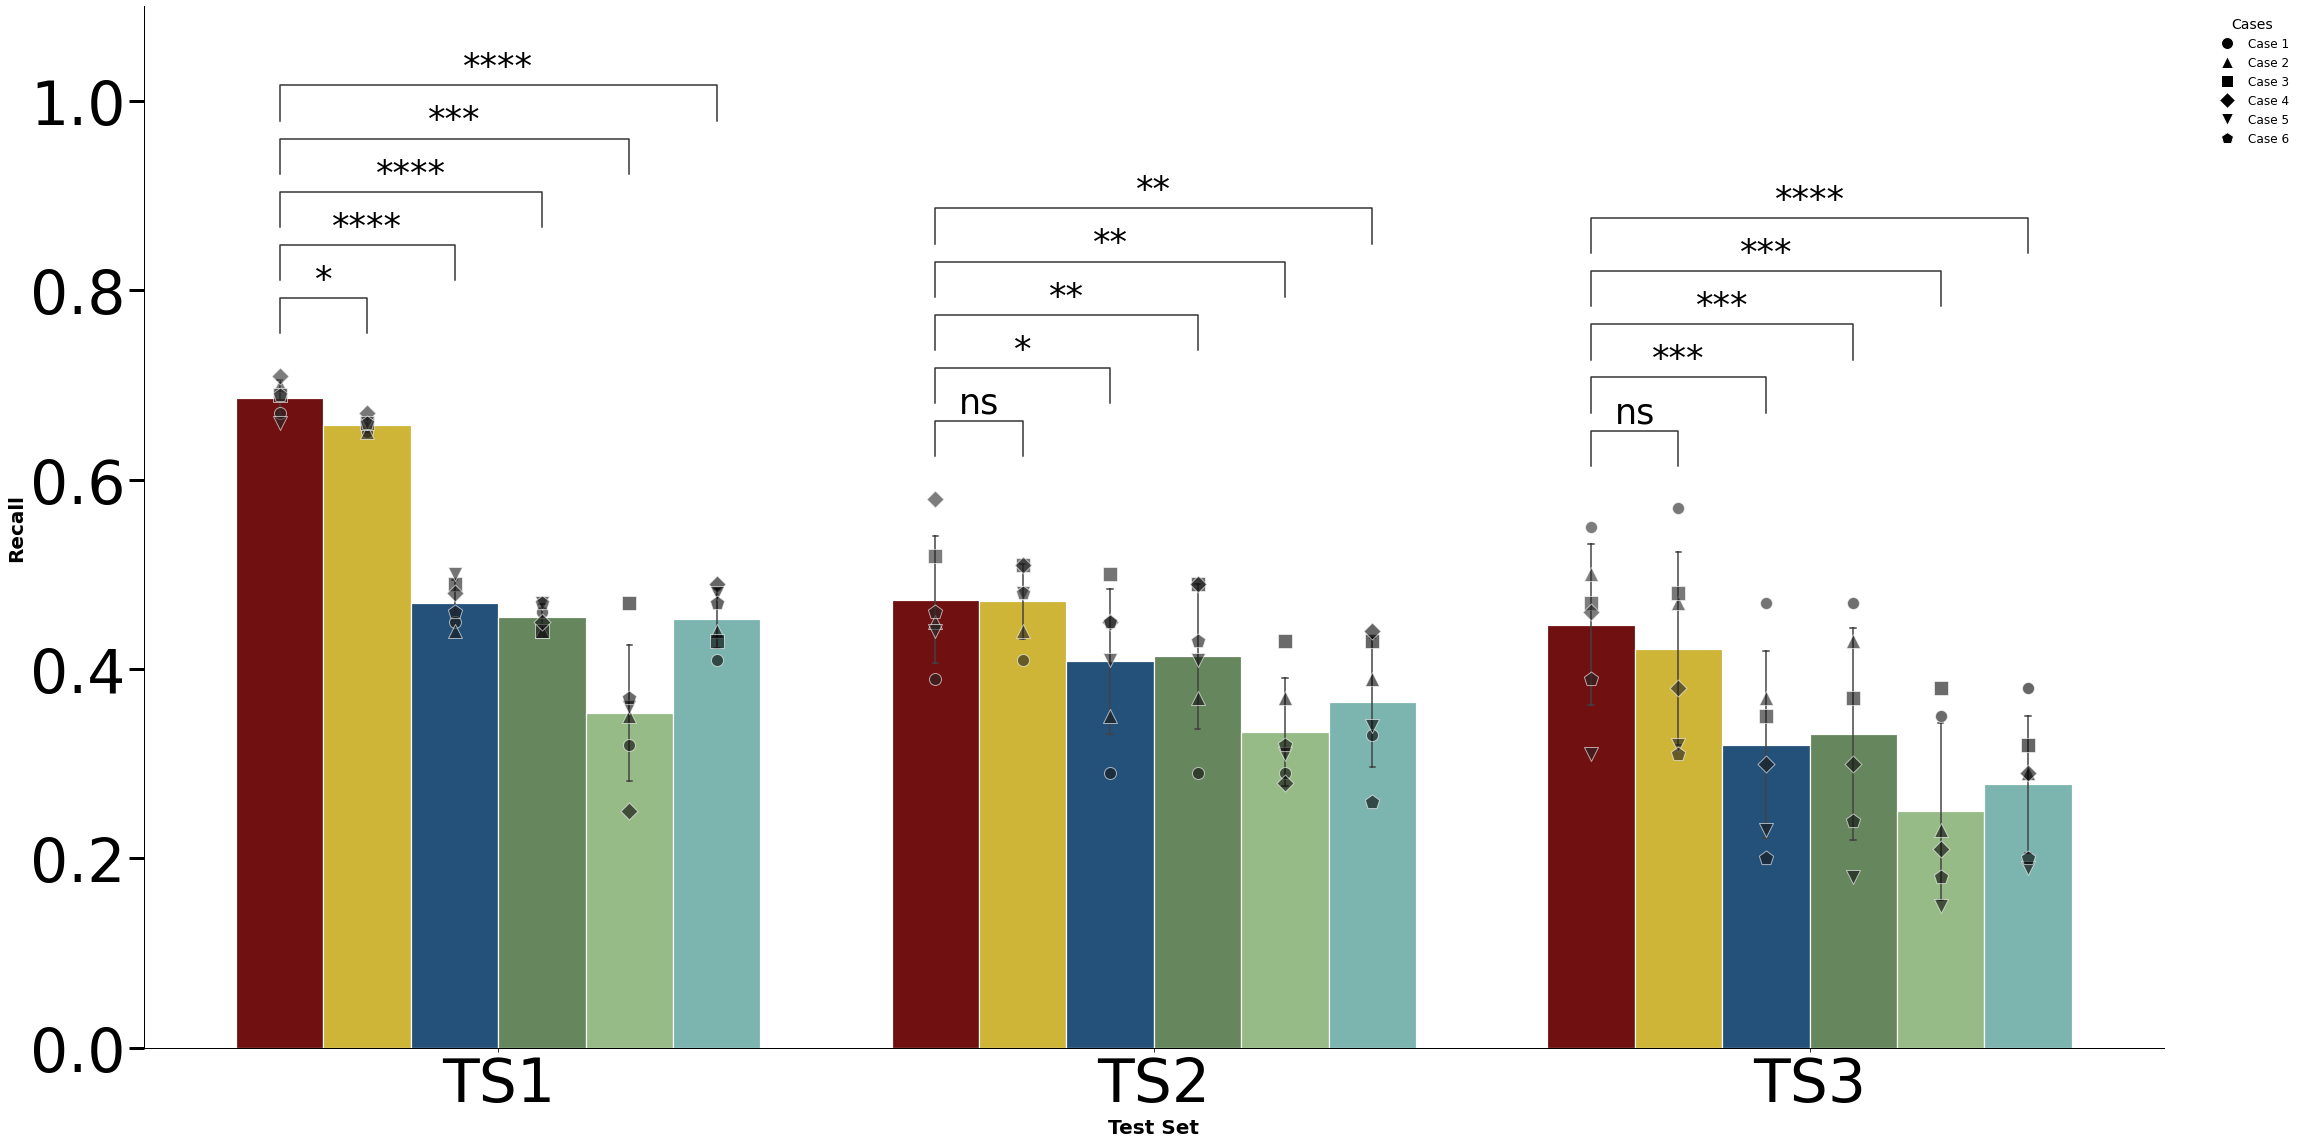

<Figure size 432x288 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import seaborn as sns
import numpy as np
from itertools import combinations

# ==========================================
# 1. SETUP DATA
# ==========================================

raw_data = {
    'TS1': {
        'base_model': [0.67, 0.7, 0.69, 0.71, 0.66, 0.69],
        'random_walk_with_topology': [0.65, 0.65, 0.66, 0.67, 0.66, 0.66],
        'random_edges': [0.45, 0.44, 0.49, 0.48, 0.5, 0.46],
        'random_pdb_edges': [0.46, 0.44, 0.44, 0.45, 0.47, 0.47],
        'random_walk_with_random_edges': [0.32, 0.35, 0.47, 0.25, 0.36, 0.37],
        'random_walk_with_topology_v2': [0.41, 0.44, 0.43, 0.49, 0.48, 0.47],
    },
    'TS2': {
        'base_model': [0.39, 0.45, 0.52, 0.58, 0.44, 0.46],
        'random_walk_with_topology': [0.41, 0.44, 0.51, 0.51, 0.48, 0.48],
        'random_edges': [0.29, 0.35, 0.5, 0.45, 0.41, 0.45],
        'random_pdb_edges': [0.29, 0.37, 0.49, 0.49, 0.41, 0.43],
        'random_walk_with_random_edges': [0.29, 0.37, 0.43, 0.28, 0.31, 0.32],
        'random_walk_with_topology_v2': [0.33, 0.39, 0.43, 0.44, 0.34, 0.26],
    },
    'TS3': {
        'base_model': [0.55, 0.5, 0.47, 0.46, 0.31, 0.39],
        'random_walk_with_topology': [0.57, 0.47, 0.48, 0.38, 0.32, 0.31],
        'random_edges': [0.47, 0.37, 0.35, 0.3, 0.23, 0.2],
        'random_pdb_edges': [0.47, 0.43, 0.37, 0.3, 0.18, 0.24],
        'random_walk_with_random_edges': [0.35, 0.23, 0.38, 0.21, 0.15, 0.18],
        'random_walk_with_topology_v2': [0.38, 0.29, 0.32, 0.29, 0.19, 0.2],
    },
}


# Convert to DataFrame
data_list = []
for ts, models_dict in raw_data.items():
    for model, scores in models_dict.items():
        for i, score in enumerate(scores):
            data_list.append({
                'Test Set': ts, 
                'Model': model, 
                'Precision': score,
                'Run': i 
            })

df = pd.DataFrame(data_list)

# ==========================================
# 2. DEFINE AESTHETICS
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.0

models = ['base_model', 'random_walk_with_topology',  'random_edges','random_pdb_edges', 'random_walk_with_random_edges', 
          'random_walk_with_topology_v2' ]

colors_hex = [
    "#800000",  
    "#E9C61D",
    "#155289",  
    "#628D56",
    "#94C47D",
    "#72BEB7"
]
palette = dict(zip(models, colors_hex))

# --- DEFINING 6 MARKERS FOR 6 CASES ---
# Markers: Circle, Triangle Up, Square, Diamond, Triangle Down, Pentagon
run_markers = ['o', '^', 's', 'D', 'v', 'p']
run_sizes   = [12, 14, 14, 12, 14, 15] 
run_labels  = ['Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6']

# ==========================================
# 3. PLOTTING
# ==========================================
plt.figure(figsize=(32, 16)) # Increased width slightly for legends




#plt.axhline(y=0.3, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, zorder=0)


# A. Bar Plot (Base)
ax = sns.barplot(
    data=df, 
    x="Test Set", 
    y="Precision", 
    hue="Model", 
    hue_order=models,
    palette=palette,
    ci='sd',            
    errwidth=1.5,      
    capsize=0.05,      
    edgecolor='white', 
    linewidth=1.2,
    alpha=1 # Slightly transparent bars to let dots pop
)

# B. Strip Plot Loop (Shapes for Runs)
# Looping 0 to 5 to cover all 6 cases
for run_id in range(6):
    subset = df[df['Run'] == run_id]
    if subset.empty: continue
        
    sns.stripplot(
        data=subset,
        x="Test Set",
        y="Precision",
        hue="Model",
        hue_order=models,
        dodge=True,      
        jitter=0.15,      # VISIBILITY FIX: Jitter prevents perfect overlap
        marker=run_markers[run_id], 
        size=run_sizes[run_id],     
        color='black',   
        alpha=0.6,        # VISIBILITY FIX: Transparency helps see stacked dots
        edgecolor='white',# VISIBILITY FIX: White border defines shape edges
        linewidth=1,
        ax=ax,
        zorder=10        
    )

# ==========================================
# 4. STATISTICAL ANNOTATION (Modified)
# ==========================================
try:
    from statannotations.Annotator import Annotator
    
    box_pairs = []
    test_sets = df['Test Set'].unique()
    
    # Define your control model
    control_model = 'base_model' 
    # List of models to compare against the control
    other_models = [m for m in models if m != control_model]
    
    for ts in test_sets:
        for other in other_models:
            # Only create pairs that involve the base_model
            box_pairs.append(((ts, control_model), (ts, other)))

    annotator = Annotator(ax, box_pairs, data=df, x="Test Set", y="Precision", hue="Model")
    
    # Using t-test_ind as it's more robust for general comparisons
    annotator.configure(test='t-test_paired', text_format='star', loc='inside', 
                        # --- ADD THESE PARAMETERS ---
                        line_offset=0,        # Gap between the bracket and the stars/text
                        line_offset_to_group=0, # Gap between the top of the bar/points and the first bracket
                        line_height=0.05,          # Gap between multiple stacked brackets
                        # ----------------------------
                        verbose=0, line_width=1.5)
    annotator.apply_and_annotate()
    
    # Styling the stars
    for text_obj in ax.texts:
        txt = text_obj.get_text()
        if '*' in txt or 'ns' in txt:
            text_obj.set_fontsize(35) # Slightly smaller to avoid overlap
            #text_obj.set_fontweight('bold')

except ImportError:
    print("[!] Install statannotations to see significance stars.")
# ==========================================
# 5. LEGENDS AND POLISH
# ==========================================
sns.despine(top=True, right=True)
plt.ylabel("Recall", fontweight='bold', fontsize=20)
plt.xlabel("Test Set", fontweight='bold', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=60)
ax.tick_params(
    axis='y', 
    which='major', 
    direction='out', 
    length=15,    # Increase this to make the "bar" longer
    width=3,     # Increase this to make the "bar" thicker
    labelsize=60 # Keep your existing label size
)
plt.ylim(0, 1.1) # Added headroom for stars

# Legend 1: Models
legend_handles = [mpatches.Patch(color=palette[m], label=m) for m in models]
legend1 = plt.legend(
    handles=legend_handles, 
    title='Models', title_fontsize=14,
    frameon=False, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.2), # Moved up to avoid clash
    ncol=3, 
    fontsize=14
)
#ax.add_artist(legend1)

# Legend 2: Cases (Shapes)
shape_handles = []
for i in range(6):
    handle = mlines.Line2D([], [], color='black', marker=run_markers[i], 
                           linestyle='None', markersize=12, label=run_labels[i],
                           markeredgecolor='white', markeredgewidth=1)
    shape_handles.append(handle)

plt.legend(
    handles=shape_handles,
    title='Cases', title_fontsize=14,
    frameon=False,
    loc='upper left',       
    bbox_to_anchor=(1.02, 1), # Moved outside to the right
    fontsize=12
)



plt.tight_layout()
plt.show()
plt.savefig('figures/recall_geo_topo_comparison.png', dpi=600, bbox_inches='tight')



## Recall

<ipython-input-7-be18c05d6a34>:77: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(
<ipython-input-7-be18c05d6a34>:77: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(
<ipython-input-7-be18c05d6a34>:98: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-7-be18c05d6a34>:98: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-7-be18c05d6a34>:98: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-7-be18c05d6a34>:98: FutureWarning: 



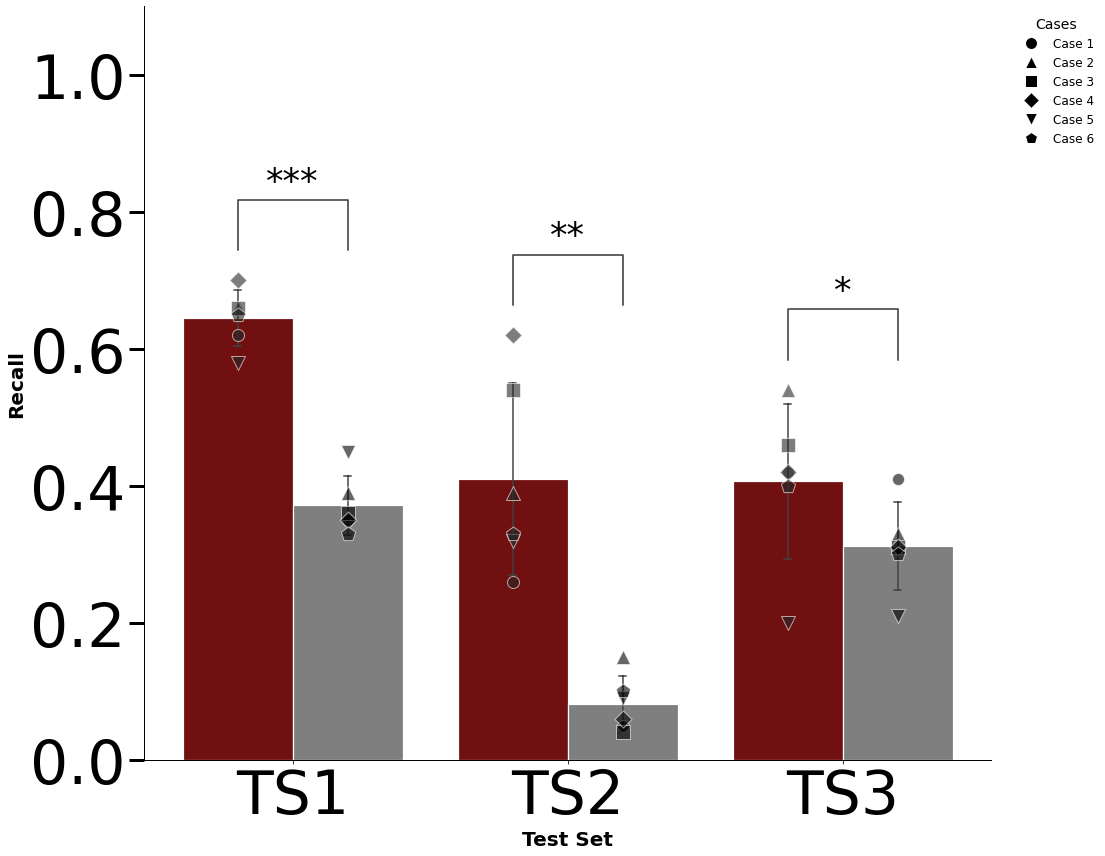

<Figure size 432x288 with 0 Axes>

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import seaborn as sns
import numpy as np
from itertools import combinations

# ==========================================
# 1. SETUP DATA
# ==========================================

raw_data = {
    'TS1': {
        'base_model': [0.62, 0.66, 0.66, 0.7, 0.58, 0.65],
        'rational_CD_random_class': [0.35, 0.39, 0.36, 0.35, 0.45, 0.33],
    },
    'TS2': {
        'base_model': [0.26, 0.39, 0.54, 0.62, 0.32, 0.33],
        'rational_CD_random_class': [0.05, 0.15, 0.04, 0.06, 0.09, 0.1]
    },
    'TS3': {
        'base_model': [0.42, 0.54, 0.46, 0.42, 0.2, 0.4],
        'rational_CD_random_class': [0.41, 0.33, 0.31, 0.31, 0.21, 0.3]
    },
}

# Convert to DataFrame
data_list = []
for ts, models_dict in raw_data.items():
    for model, scores in models_dict.items():
        for i, score in enumerate(scores):
            data_list.append({
                'Test Set': ts, 
                'Model': model, 
                'Precision': score,
                'Run': i 
            })

df = pd.DataFrame(data_list)

# ==========================================
# 2. DEFINE AESTHETICS
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.0

models = ['base_model', 'rational_CD_random_class']

colors_hex = [
    "#800000",
    "#7F7F7F",  # Grey (Neutral mid-tone)
]
    

palette = dict(zip(models, colors_hex))

# --- DEFINING 6 MARKERS FOR 6 CASES ---
# Markers: Circle, Triangle Up, Square, Diamond, Triangle Down, Pentagon
run_markers = ['o', '^', 's', 'D', 'v', 'p']
run_sizes   = [12, 14, 14, 12, 14, 15] 
run_labels  = ['Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6']

# ==========================================
# 3. PLOTTING
# ==========================================
plt.figure(figsize=(16, 12)) # Increased width slightly for legends




#plt.axhline(y=0.3, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, zorder=0)


# A. Bar Plot (Base)
ax = sns.barplot(
    data=df, 
    x="Test Set", 
    y="Precision", 
    hue="Model", 
    hue_order=models,
    palette=palette,
    ci='sd',            
    errwidth=1.5,      
    capsize=0.05,      
    edgecolor='white', 
    linewidth=1.2,
    alpha=1 # Slightly transparent bars to let dots pop
)

# B. Strip Plot Loop (Shapes for Runs)
# Looping 0 to 5 to cover all 6 cases
for run_id in range(6):
    subset = df[df['Run'] == run_id]
    if subset.empty: continue
        
    sns.stripplot(
        data=subset,
        x="Test Set",
        y="Precision",
        hue="Model",
        hue_order=models,
        dodge=True,      
        jitter=0.15,      # VISIBILITY FIX: Jitter prevents perfect overlap
        marker=run_markers[run_id], 
        size=run_sizes[run_id],     
        color='black',   
        alpha=0.6,        # VISIBILITY FIX: Transparency helps see stacked dots
        edgecolor='white',# VISIBILITY FIX: White border defines shape edges
        linewidth=1,
        ax=ax,
        zorder=10        
    )

# ==========================================
# 4. STATISTICAL ANNOTATION (Modified)
# ==========================================
try:
    from statannotations.Annotator import Annotator
    
    box_pairs = []
    test_sets = df['Test Set'].unique()
    
    # Define your control model
    control_model = 'base_model' 
    # List of models to compare against the control
    other_models = [m for m in models if m != control_model]
    
    for ts in test_sets:
        for other in other_models:
            # Only create pairs that involve the base_model
            box_pairs.append(((ts, control_model), (ts, other)))

    annotator = Annotator(ax, box_pairs, data=df, x="Test Set", y="Precision", hue="Model")
    
    # Using t-test_ind as it's more robust for general comparisons
    annotator.configure(test='t-test_paired', text_format='star', loc='inside', 
                        # --- ADD THESE PARAMETERS ---
                        line_offset=0,        # Gap between the bracket and the stars/text
                        line_offset_to_group=0.05, # Gap between the top of the bar/points and the first bracket
                        line_height=0.1,          # Gap between multiple stacked brackets
                        # ----------------------------
                        verbose=0, line_width=1.5)
    annotator.apply_and_annotate()
    
    # Styling the stars
    for text_obj in ax.texts:
        txt = text_obj.get_text()
        if '*' in txt or 'ns' in txt:
            text_obj.set_fontsize(35) # Slightly smaller to avoid overlap
            #text_obj.set_fontweight('bold')

except ImportError:
    print("[!] Install statannotations to see significance stars.")
# ==========================================
# 5. LEGENDS AND POLISH
# ==========================================
sns.despine(top=True, right=True)
plt.ylabel("Recall", fontweight='bold', fontsize=20)
plt.xlabel("Test Set", fontweight='bold', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=60)
ax.tick_params(
    axis='y', 
    which='major', 
    direction='out', 
    length=15,    # Increase this to make the "bar" longer
    width=3,     # Increase this to make the "bar" thicker
    labelsize=60 # Keep your existing label size
)
plt.ylim(0, 1.1) # Added headroom for stars

# Legend 1: Models
legend_handles = [mpatches.Patch(color=palette[m], label=m) for m in models]
legend1 = plt.legend(
    handles=legend_handles, 
    title='Models', title_fontsize=14,
    frameon=False, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.2), # Moved up to avoid clash
    ncol=3, 
    fontsize=14
)
#ax.add_artist(legend1)

# Legend 2: Cases (Shapes)
shape_handles = []
for i in range(6):
    handle = mlines.Line2D([], [], color='black', marker=run_markers[i], 
                           linestyle='None', markersize=12, label=run_labels[i],
                           markeredgecolor='white', markeredgewidth=1)
    shape_handles.append(handle)

plt.legend(
    handles=shape_handles,
    title='Cases', title_fontsize=14,
    frameon=False,
    loc='upper left',       
    bbox_to_anchor=(1.02, 1), # Moved outside to the right
    fontsize=12
)



plt.tight_layout()
plt.show()
plt.savefig('figures/recall_geo_topo_comparison.png', dpi=600, bbox_inches='tight')



<ipython-input-8-80f5b64ec123>:77: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(
<ipython-input-8-80f5b64ec123>:77: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(
<ipython-input-8-80f5b64ec123>:98: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-8-80f5b64ec123>:98: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-8-80f5b64ec123>:98: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-8-80f5b64ec123>:98: FutureWarning: 



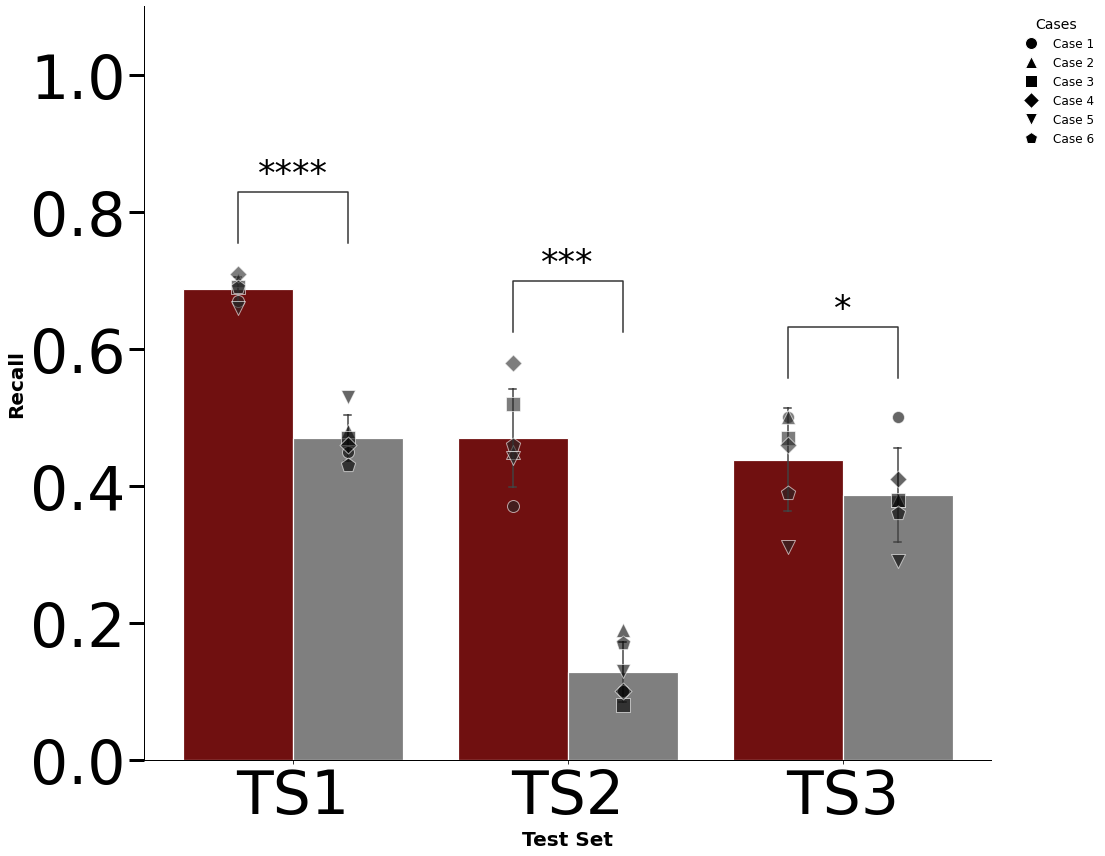

<Figure size 432x288 with 0 Axes>

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import seaborn as sns
import numpy as np
from itertools import combinations

# ==========================================
# 1. SETUP DATA
# ==========================================

raw_data = {
    'TS1': {
        'base_model': [0.67, 0.7, 0.69, 0.71, 0.66, 0.69],
        'rational_CD_random_class': [0.45, 0.48, 0.47, 0.46, 0.53, 0.43]
    },
    'TS2': {
        'base_model': [0.37, 0.45, 0.52, 0.58, 0.44, 0.46],
        'rational_CD_random_class': [0.1, 0.19, 0.08, 0.1, 0.13, 0.17]
    },
    'TS3': {
        'base_model': [0.5, 0.5, 0.47, 0.46, 0.31, 0.39],
        'rational_CD_random_class': [0.5, 0.38, 0.38, 0.41, 0.29, 0.36]
    },
}

# Convert to DataFrame
data_list = []
for ts, models_dict in raw_data.items():
    for model, scores in models_dict.items():
        for i, score in enumerate(scores):
            data_list.append({
                'Test Set': ts, 
                'Model': model, 
                'Precision': score,
                'Run': i 
            })

df = pd.DataFrame(data_list)

# ==========================================
# 2. DEFINE AESTHETICS
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.0

models = ['base_model', 'rational_CD_random_class']

colors_hex = [
    "#800000",
    "#7F7F7F",  # Grey (Neutral mid-tone)
]
    

palette = dict(zip(models, colors_hex))

# --- DEFINING 6 MARKERS FOR 6 CASES ---
# Markers: Circle, Triangle Up, Square, Diamond, Triangle Down, Pentagon
run_markers = ['o', '^', 's', 'D', 'v', 'p']
run_sizes   = [12, 14, 14, 12, 14, 15] 
run_labels  = ['Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6']

# ==========================================
# 3. PLOTTING
# ==========================================
plt.figure(figsize=(16, 12)) # Increased width slightly for legends




#plt.axhline(y=0.3, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, zorder=0)


# A. Bar Plot (Base)
ax = sns.barplot(
    data=df, 
    x="Test Set", 
    y="Precision", 
    hue="Model", 
    hue_order=models,
    palette=palette,
    ci='sd',            
    errwidth=1.5,      
    capsize=0.05,      
    edgecolor='white', 
    linewidth=1.2,
    alpha=1 # Slightly transparent bars to let dots pop
)

# B. Strip Plot Loop (Shapes for Runs)
# Looping 0 to 5 to cover all 6 cases
for run_id in range(6):
    subset = df[df['Run'] == run_id]
    if subset.empty: continue
        
    sns.stripplot(
        data=subset,
        x="Test Set",
        y="Precision",
        hue="Model",
        hue_order=models,
        dodge=True,      
        jitter=0.15,      # VISIBILITY FIX: Jitter prevents perfect overlap
        marker=run_markers[run_id], 
        size=run_sizes[run_id],     
        color='black',   
        alpha=0.6,        # VISIBILITY FIX: Transparency helps see stacked dots
        edgecolor='white',# VISIBILITY FIX: White border defines shape edges
        linewidth=1,
        ax=ax,
        zorder=10        
    )

# ==========================================
# 4. STATISTICAL ANNOTATION (Modified)
# ==========================================
try:
    from statannotations.Annotator import Annotator
    
    box_pairs = []
    test_sets = df['Test Set'].unique()
    
    # Define your control model
    control_model = 'base_model' 
    # List of models to compare against the control
    other_models = [m for m in models if m != control_model]
    
    for ts in test_sets:
        for other in other_models:
            # Only create pairs that involve the base_model
            box_pairs.append(((ts, control_model), (ts, other)))

    annotator = Annotator(ax, box_pairs, data=df, x="Test Set", y="Precision", hue="Model")
    
    # Using t-test_ind as it's more robust for general comparisons
    annotator.configure(test='t-test_paired', text_format='star', loc='inside', 
                        # --- ADD THESE PARAMETERS ---
                        line_offset=0,        # Gap between the bracket and the stars/text
                        line_offset_to_group=0.05, # Gap between the top of the bar/points and the first bracket
                        line_height=0.1,          # Gap between multiple stacked brackets
                        # ----------------------------
                        verbose=0, line_width=1.5)
    annotator.apply_and_annotate()
    
    # Styling the stars
    for text_obj in ax.texts:
        txt = text_obj.get_text()
        if '*' in txt or 'ns' in txt:
            text_obj.set_fontsize(35) # Slightly smaller to avoid overlap
            #text_obj.set_fontweight('bold')

except ImportError:
    print("[!] Install statannotations to see significance stars.")
# ==========================================
# 5. LEGENDS AND POLISH
# ==========================================
sns.despine(top=True, right=True)
plt.ylabel("Recall", fontweight='bold', fontsize=20)
plt.xlabel("Test Set", fontweight='bold', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=60)
ax.tick_params(
    axis='y', 
    which='major', 
    direction='out', 
    length=15,    # Increase this to make the "bar" longer
    width=3,     # Increase this to make the "bar" thicker
    labelsize=60 # Keep your existing label size
)
plt.ylim(0, 1.1) # Added headroom for stars

# Legend 1: Models
legend_handles = [mpatches.Patch(color=palette[m], label=m) for m in models]
legend1 = plt.legend(
    handles=legend_handles, 
    title='Models', title_fontsize=14,
    frameon=False, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.2), # Moved up to avoid clash
    ncol=3, 
    fontsize=14
)
#ax.add_artist(legend1)

# Legend 2: Cases (Shapes)
shape_handles = []
for i in range(6):
    handle = mlines.Line2D([], [], color='black', marker=run_markers[i], 
                           linestyle='None', markersize=12, label=run_labels[i],
                           markeredgecolor='white', markeredgewidth=1)
    shape_handles.append(handle)

plt.legend(
    handles=shape_handles,
    title='Cases', title_fontsize=14,
    frameon=False,
    loc='upper left',       
    bbox_to_anchor=(1.02, 1), # Moved outside to the right
    fontsize=12
)



plt.tight_layout()
plt.show()
plt.savefig('figures/recall_geo_topo_comparison.png', dpi=600, bbox_inches='tight')



# Fig 7

## Recall

<ipython-input-9-365b1c230736>:87: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(
<ipython-input-9-365b1c230736>:87: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(
<ipython-input-9-365b1c230736>:108: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-9-365b1c230736>:108: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-9-365b1c230736>:108: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-9-365b1c230736>:108: FutureWarning

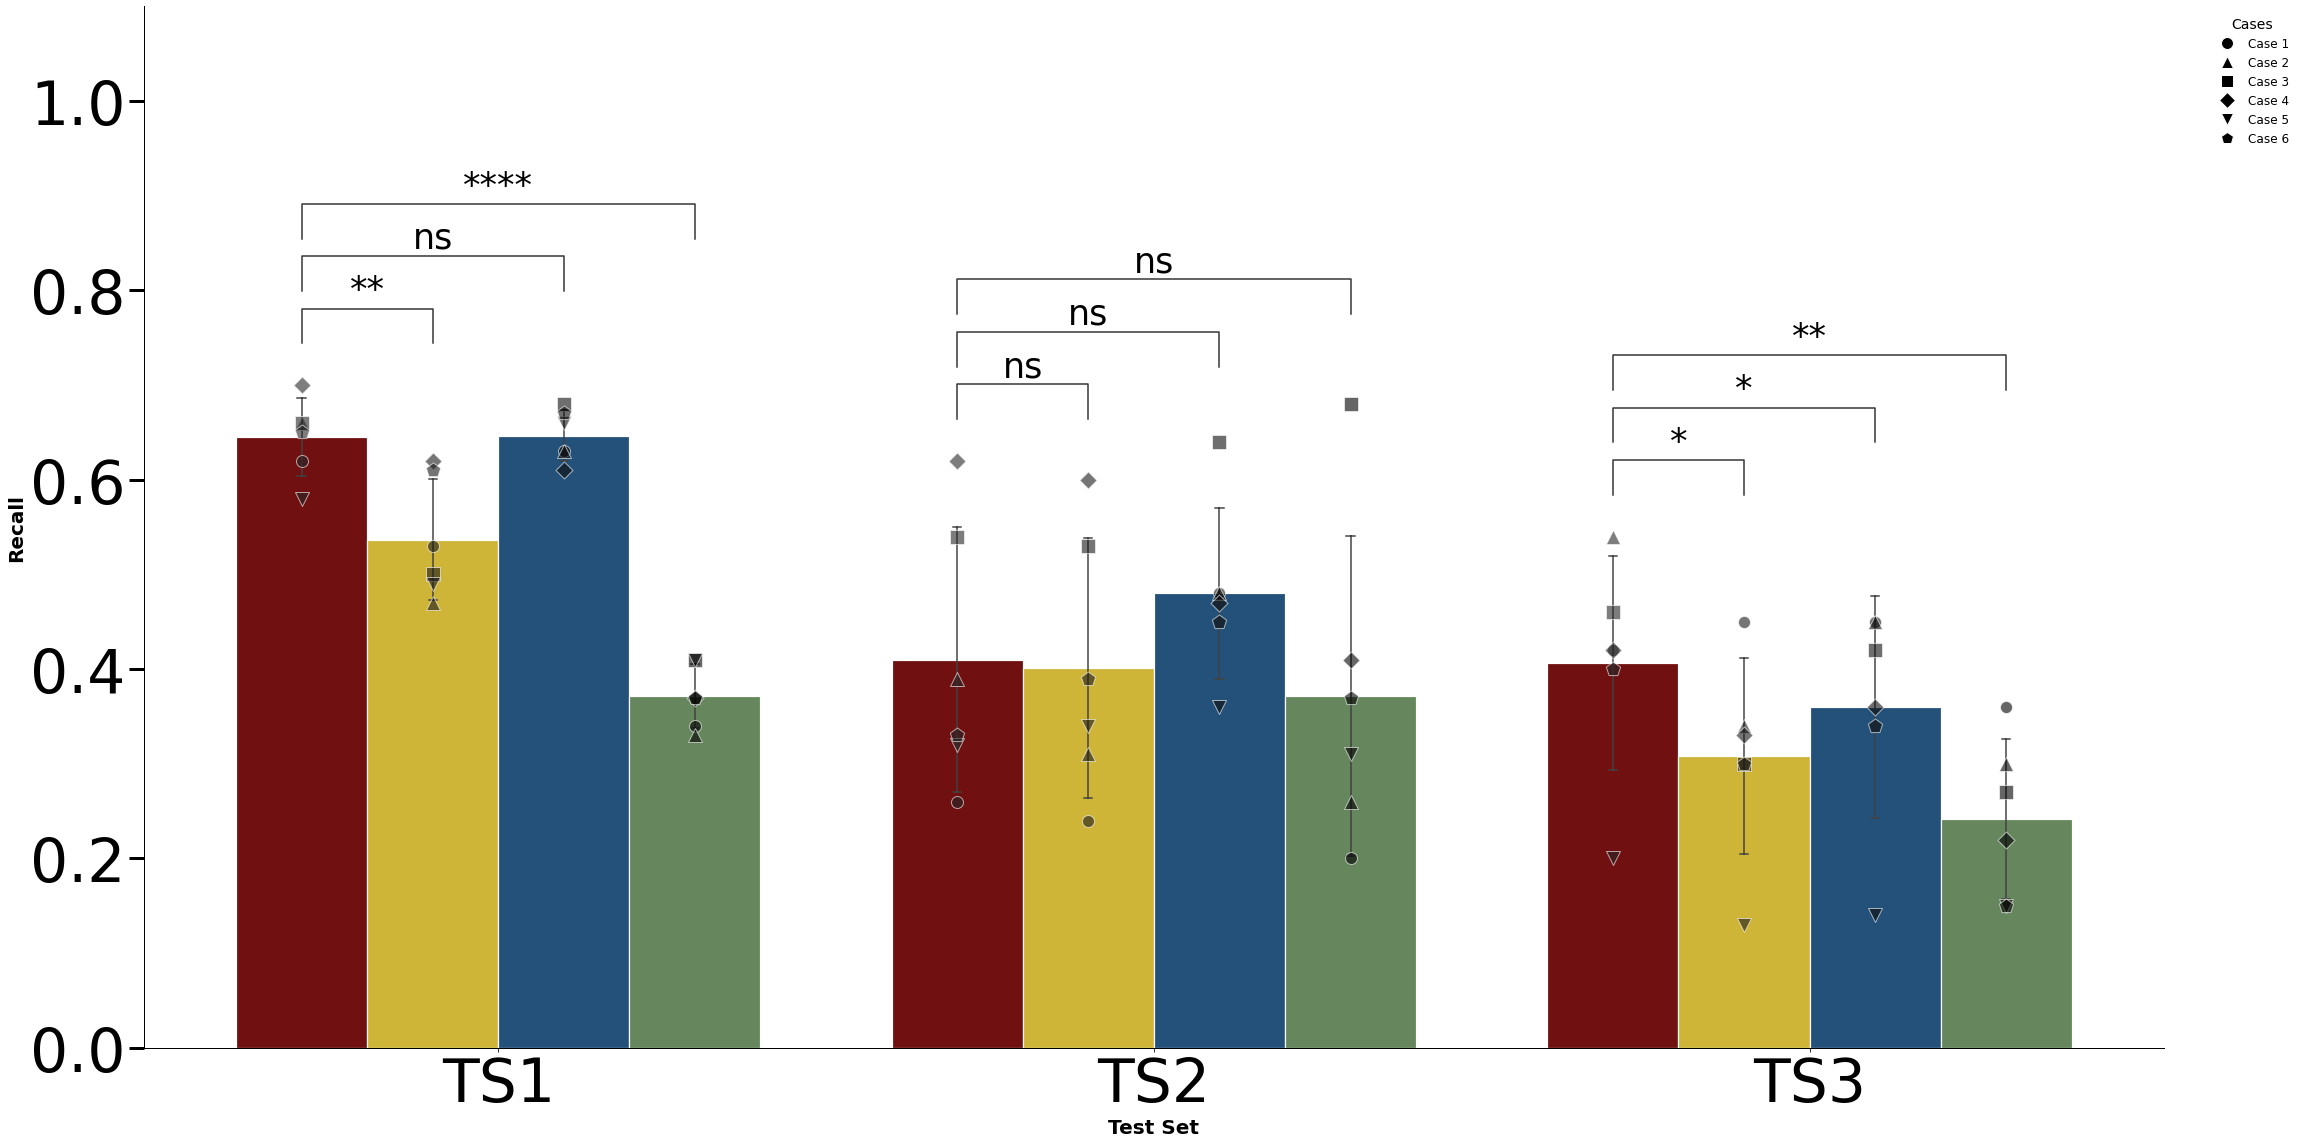

<Figure size 432x288 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import seaborn as sns
import numpy as np
from itertools import combinations

# ==========================================
# 1. SETUP DATA
# ==========================================

raw_data = {
    'TS1': {
        'base_model': [0.62, 0.66, 0.66, 0.7, 0.58, 0.65],
        'no_nonc_edges': [0.53, 0.47, 0.5, 0.62, 0.49, 0.61],
        'no_peptide_edge': [0.63, 0.63, 0.68, 0.61, 0.66, 0.67],
        'random_edges': [0.34, 0.33, 0.41, 0.37, 0.41, 0.37],
    },
    'TS2': {
        'base_model': [0.26, 0.39, 0.54, 0.62, 0.32, 0.33],
        'no_nonc_edges': [0.24, 0.31, 0.53, 0.6, 0.34, 0.39],
        'no_peptide_edge': [0.48, 0.48, 0.64, 0.47, 0.36, 0.45],
        'random_edges': [0.2, 0.26, 0.68, 0.41, 0.31, 0.37],
    },
    'TS3': {
        'base_model': [0.42, 0.54, 0.46, 0.42, 0.2, 0.4],
        'no_nonc_edges': [0.45, 0.34, 0.3, 0.33, 0.13, 0.3],
        'no_peptide_edge': [0.45, 0.45, 0.42, 0.36, 0.14, 0.34],
        'random_edges': [0.36, 0.3, 0.27, 0.22, 0.15, 0.15],
    },
}



# Convert to DataFrame
data_list = []
for ts, models_dict in raw_data.items():
    for model, scores in models_dict.items():
        for i, score in enumerate(scores):
            data_list.append({
                'Test Set': ts, 
                'Model': model, 
                'Precision': score,
                'Run': i 
            })

df = pd.DataFrame(data_list)

# ==========================================
# 2. DEFINE AESTHETICS
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.0

models = [ 'base_model', 'no_nonc_edges', 'no_peptide_edge', 'random_edges']

colors_hex = [
    "#800000",  
    "#E9C61D",
    "#155289",  
    "#628D56",
    "#94C47D",
    "#72BEB7"
]
palette = dict(zip(models, colors_hex))

# --- DEFINING 6 MARKERS FOR 6 CASES ---
# Markers: Circle, Triangle Up, Square, Diamond, Triangle Down, Pentagon
run_markers = ['o', '^', 's', 'D', 'v', 'p']
run_sizes   = [12, 14, 14, 12, 14, 15] 
run_labels  = ['Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6']

# ==========================================
# 3. PLOTTING
# ==========================================
plt.figure(figsize=(32, 16)) # Increased width slightly for legends




#plt.axhline(y=0.3, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, zorder=0)


# A. Bar Plot (Base)
ax = sns.barplot(
    data=df, 
    x="Test Set", 
    y="Precision", 
    hue="Model", 
    hue_order=models,
    palette=palette,
    ci='sd',            
    errwidth=1.5,      
    capsize=0.05,      
    edgecolor='white', 
    linewidth=1.2,
    alpha=1 # Slightly transparent bars to let dots pop
)

# B. Strip Plot Loop (Shapes for Runs)
# Looping 0 to 5 to cover all 6 cases
for run_id in range(6):
    subset = df[df['Run'] == run_id]
    if subset.empty: continue
        
    sns.stripplot(
        data=subset,
        x="Test Set",
        y="Precision",
        hue="Model",
        hue_order=models,
        dodge=True,      
        jitter=0.15,      # VISIBILITY FIX: Jitter prevents perfect overlap
        marker=run_markers[run_id], 
        size=run_sizes[run_id],     
        color='black',   
        alpha=0.6,        # VISIBILITY FIX: Transparency helps see stacked dots
        edgecolor='white',# VISIBILITY FIX: White border defines shape edges
        linewidth=1,
        ax=ax,
        zorder=10        
    )

# ==========================================
# 4. STATISTICAL ANNOTATION (Modified)
# ==========================================
try:
    from statannotations.Annotator import Annotator
    
    box_pairs = []
    test_sets = df['Test Set'].unique()
    
    # Define your control model
    control_model = 'base_model' 
    # List of models to compare against the control
    other_models = [m for m in models if m != control_model]
    
    for ts in test_sets:
        for other in other_models:
            # Only create pairs that involve the base_model
            box_pairs.append(((ts, control_model), (ts, other)))

    annotator = Annotator(ax, box_pairs, data=df, x="Test Set", y="Precision", hue="Model")
    
    # Using t-test_ind as it's more robust for general comparisons
    annotator.configure(test='t-test_paired', text_format='star', loc='inside', 
                        # --- ADD THESE PARAMETERS ---
                        line_offset=0,        # Gap between the bracket and the stars/text
                        line_offset_to_group=0, # Gap between the top of the bar/points and the first bracket
                        line_height=0.05,          # Gap between multiple stacked brackets
                        # ----------------------------
                        verbose=0, line_width=1.5)
    annotator.apply_and_annotate()
    
    # Styling the stars
    for text_obj in ax.texts:
        txt = text_obj.get_text()
        if '*' in txt or 'ns' in txt:
            text_obj.set_fontsize(35) # Slightly smaller to avoid overlap
            #text_obj.set_fontweight('bold')

except ImportError:
    print("[!] Install statannotations to see significance stars.")
# ==========================================
# 5. LEGENDS AND POLISH
# ==========================================
sns.despine(top=True, right=True)
plt.ylabel("Recall", fontweight='bold', fontsize=20)
plt.xlabel("Test Set", fontweight='bold', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=60)
ax.tick_params(
    axis='y', 
    which='major', 
    direction='out', 
    length=15,    # Increase this to make the "bar" longer
    width=3,     # Increase this to make the "bar" thicker
    labelsize=60 # Keep your existing label size
)
plt.ylim(0, 1.1) # Added headroom for stars

# Legend 1: Models
legend_handles = [mpatches.Patch(color=palette[m], label=m) for m in models]
legend1 = plt.legend(
    handles=legend_handles, 
    title='Models', title_fontsize=14,
    frameon=False, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.2), # Moved up to avoid clash
    ncol=3, 
    fontsize=14
)
#ax.add_artist(legend1)

# Legend 2: Cases (Shapes)
shape_handles = []
for i in range(6):
    handle = mlines.Line2D([], [], color='black', marker=run_markers[i], 
                           linestyle='None', markersize=12, label=run_labels[i],
                           markeredgecolor='white', markeredgewidth=1)
    shape_handles.append(handle)

plt.legend(
    handles=shape_handles,
    title='Cases', title_fontsize=14,
    frameon=False,
    loc='upper left',       
    bbox_to_anchor=(1.02, 1), # Moved outside to the right
    fontsize=12
)



plt.tight_layout()
plt.show()
plt.savefig('figures/recall_geo_topo_comparison.png', dpi=600, bbox_inches='tight')



## F1

<ipython-input-10-1957581ab43f>:85: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(
<ipython-input-10-1957581ab43f>:85: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(
<ipython-input-10-1957581ab43f>:106: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-10-1957581ab43f>:106: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-10-1957581ab43f>:106: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(
<ipython-input-10-1957581ab43f>:106: FutureW

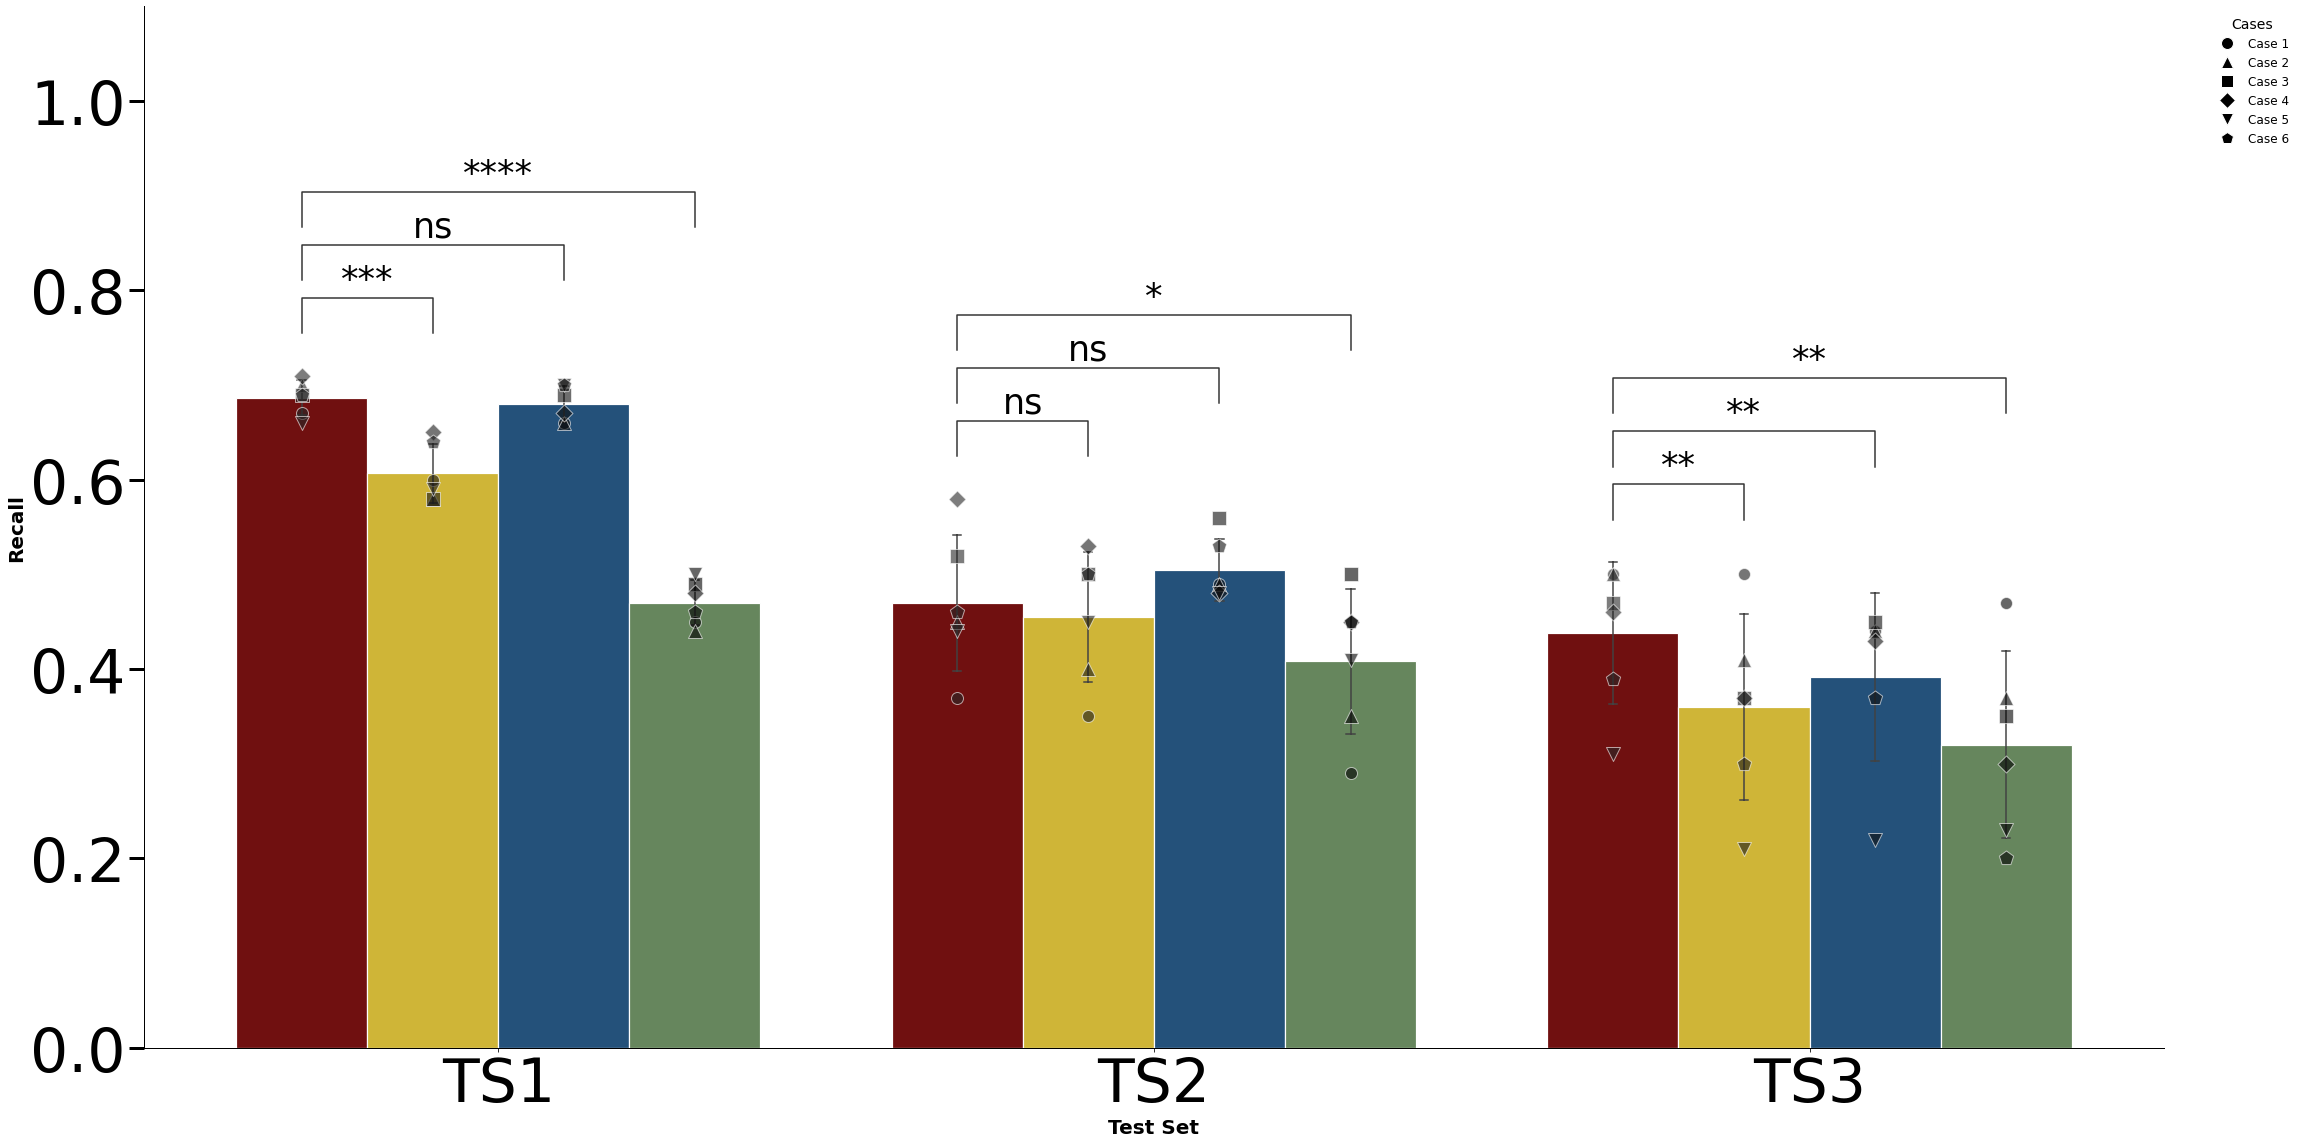

<Figure size 432x288 with 0 Axes>

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import pandas as pd
import seaborn as sns
import numpy as np
from itertools import combinations

# ==========================================
# 1. SETUP DATA
# ==========================================

raw_data= {
    'TS1': {
        'base_model': [0.67, 0.7, 0.69, 0.71, 0.66, 0.69],
        'no_nonc_edges': [0.6, 0.58, 0.58, 0.65, 0.59, 0.64],
        'no_peptide_edge': [0.66, 0.66, 0.69, 0.67, 0.7, 0.7],
        'random_edges': [0.45, 0.44, 0.49, 0.48, 0.5, 0.46],
    },
    'TS2': {
        'base_model': [0.37, 0.45, 0.52, 0.58, 0.44, 0.46],
        'no_nonc_edges': [0.35, 0.4, 0.5, 0.53, 0.45, 0.5],
        'no_peptide_edge': [0.49, 0.49, 0.56, 0.48, 0.48, 0.53],
        'random_edges': [0.29, 0.35, 0.5, 0.45, 0.41, 0.45],
    },
    'TS3': {
        'base_model': [0.5, 0.5, 0.47, 0.46, 0.31, 0.39],
        'no_nonc_edges': [0.5, 0.41, 0.37, 0.37, 0.21, 0.3],
        'no_peptide_edge': [0.44, 0.44, 0.45, 0.43, 0.22, 0.37],
        'random_edges': [0.47, 0.37, 0.35, 0.3, 0.23, 0.2],
    },
}

# Convert to DataFrame
data_list = []
for ts, models_dict in raw_data.items():
    for model, scores in models_dict.items():
        for i, score in enumerate(scores):
            data_list.append({
                'Test Set': ts, 
                'Model': model, 
                'Precision': score,
                'Run': i 
            })

df = pd.DataFrame(data_list)

# ==========================================
# 2. DEFINE AESTHETICS
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.0

models = [ 'base_model', 'no_nonc_edges', 'no_peptide_edge', 'random_edges']

colors_hex = [
    "#800000",  
    "#E9C61D",
    "#155289",  
    "#628D56",
    "#94C47D",
    "#72BEB7"
]
palette = dict(zip(models, colors_hex))

# --- DEFINING 6 MARKERS FOR 6 CASES ---
# Markers: Circle, Triangle Up, Square, Diamond, Triangle Down, Pentagon
run_markers = ['o', '^', 's', 'D', 'v', 'p']
run_sizes   = [12, 14, 14, 12, 14, 15] 
run_labels  = ['Case 1', 'Case 2', 'Case 3', 'Case 4', 'Case 5', 'Case 6']

# ==========================================
# 3. PLOTTING
# ==========================================
plt.figure(figsize=(32, 16)) # Increased width slightly for legends




#plt.axhline(y=0.3, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, zorder=0)


# A. Bar Plot (Base)
ax = sns.barplot(
    data=df, 
    x="Test Set", 
    y="Precision", 
    hue="Model", 
    hue_order=models,
    palette=palette,
    ci='sd',            
    errwidth=1.5,      
    capsize=0.05,      
    edgecolor='white', 
    linewidth=1.2,
    alpha=1 # Slightly transparent bars to let dots pop
)

# B. Strip Plot Loop (Shapes for Runs)
# Looping 0 to 5 to cover all 6 cases
for run_id in range(6):
    subset = df[df['Run'] == run_id]
    if subset.empty: continue
        
    sns.stripplot(
        data=subset,
        x="Test Set",
        y="Precision",
        hue="Model",
        hue_order=models,
        dodge=True,      
        jitter=0.15,      # VISIBILITY FIX: Jitter prevents perfect overlap
        marker=run_markers[run_id], 
        size=run_sizes[run_id],     
        color='black',   
        alpha=0.6,        # VISIBILITY FIX: Transparency helps see stacked dots
        edgecolor='white',# VISIBILITY FIX: White border defines shape edges
        linewidth=1,
        ax=ax,
        zorder=10        
    )

# ==========================================
# 4. STATISTICAL ANNOTATION (Modified)
# ==========================================
try:
    from statannotations.Annotator import Annotator
    
    box_pairs = []
    test_sets = df['Test Set'].unique()
    
    # Define your control model
    control_model = 'base_model' 
    # List of models to compare against the control
    other_models = [m for m in models if m != control_model]
    
    for ts in test_sets:
        for other in other_models:
            # Only create pairs that involve the base_model
            box_pairs.append(((ts, control_model), (ts, other)))

    annotator = Annotator(ax, box_pairs, data=df, x="Test Set", y="Precision", hue="Model")
    
    # Using t-test_ind as it's more robust for general comparisons
    annotator.configure(test='t-test_paired', text_format='star', loc='inside', 
                        # --- ADD THESE PARAMETERS ---
                        line_offset=0,        # Gap between the bracket and the stars/text
                        line_offset_to_group=0, # Gap between the top of the bar/points and the first bracket
                        line_height=0.05,          # Gap between multiple stacked brackets
                        # ----------------------------
                        verbose=0, line_width=1.5)
    annotator.apply_and_annotate()
    
    # Styling the stars
    for text_obj in ax.texts:
        txt = text_obj.get_text()
        if '*' in txt or 'ns' in txt:
            text_obj.set_fontsize(35) # Slightly smaller to avoid overlap
            #text_obj.set_fontweight('bold')

except ImportError:
    print("[!] Install statannotations to see significance stars.")
# ==========================================
# 5. LEGENDS AND POLISH
# ==========================================
sns.despine(top=True, right=True)
plt.ylabel("Recall", fontweight='bold', fontsize=20)
plt.xlabel("Test Set", fontweight='bold', fontsize=20)
ax.tick_params(axis='both', which='major', labelsize=60)
ax.tick_params(
    axis='y', 
    which='major', 
    direction='out', 
    length=15,    # Increase this to make the "bar" longer
    width=3,     # Increase this to make the "bar" thicker
    labelsize=60 # Keep your existing label size
)
plt.ylim(0, 1.1) # Added headroom for stars

# Legend 1: Models
legend_handles = [mpatches.Patch(color=palette[m], label=m) for m in models]
legend1 = plt.legend(
    handles=legend_handles, 
    title='Models', title_fontsize=14,
    frameon=False, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 1.2), # Moved up to avoid clash
    ncol=3, 
    fontsize=14
)
#ax.add_artist(legend1)

# Legend 2: Cases (Shapes)
shape_handles = []
for i in range(6):
    handle = mlines.Line2D([], [], color='black', marker=run_markers[i], 
                           linestyle='None', markersize=12, label=run_labels[i],
                           markeredgecolor='white', markeredgewidth=1)
    shape_handles.append(handle)

plt.legend(
    handles=shape_handles,
    title='Cases', title_fontsize=14,
    frameon=False,
    loc='upper left',       
    bbox_to_anchor=(1.02, 1), # Moved outside to the right
    fontsize=12
)



plt.tight_layout()
plt.show()
plt.savefig('figures/recall_geo_topo_comparison.png', dpi=600, bbox_inches='tight')

